In [1]:
import geopandas as gpd
import pandas as pd

basline_blocks = gpd.read_file('./data/gatchina/blocks_agg_with_indicators.geojson')
basline_blocks.head()

,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,is_living,...,area_accessibility,fsi,gsi,mxi,l,osr,share_living,share_non_living,morphotype,geometry
0,0.690207,0.211718,0.055976,0.0,0.042093,0.0,0.0,LandUse.RESIDENTIAL,0.690207,6.0,...,10.063987,0.012109,0.008829,0.091908,1.371459,81.852753,0.126048,1.245411,individual residential,"POLYGON ((30.09367 59.55207, 30.09375 59.55215..."
1,0.970519,0.029484,0.000000,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.970519,13.0,...,10.210398,0.212156,0.036428,0.712492,5.824002,4.541808,4.149554,1.674447,mid-rise,"POLYGON ((30.09448 59.56164, 30.09448 59.56164..."
2,0.936589,0.010562,0.052849,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.936589,15.0,...,8.669212,0.303551,0.056576,0.786029,5.365401,3.107955,4.217362,1.148039,mid-rise,"POLYGON ((30.12546 59.58002, 30.12541 59.57998..."
3,0.121353,0.819171,0.059489,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.819171,2.0,...,7.467434,0.173716,0.075903,0.198114,2.288643,5.319595,0.453413,1.835230,low-rise model,"POLYGON ((30.12501 59.56588, 30.12497 59.56582..."
4,0.068737,0.931312,0.000000,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.931312,2.0,...,8.285434,0.156696,0.071648,0.095598,2.187029,5.924533,0.209075,1.977953,low-rise model,"POLYGON ((30.1249 59.56574, 30.12497 59.56582,..."


In [2]:
cols = [
    'residential','business','recreation','industrial','transport','special',
    'agriculture','land_use','share','footprint_area','build_floor_area',
    'living_area','non_living_area','population','site_area','fsi','gsi',
    'mxi','l','morphotype','area_accessibility', 'geometry'
]
basline_blocks = basline_blocks[cols]


In [3]:
from catboost import CatBoostRegressor
model = CatBoostRegressor()
model.load_model('./data/catboost_land_value_no_services.cbm')  # модель на лог-цене
print(len(model.feature_names_))

101


In [4]:
feature_cols = [
'residential','business','recreation','industrial','transport','special',
'agriculture','land_use','share','footprint_area','build_floor_area',
'living_area','non_living_area','population','site_area','fsi','gsi',
'mxi','l','morphotype','area_accessibility'
]
cat_features = ['land_use', 'morphotype']
numeric_feats = [c for c in feature_cols if c not in cat_features]

In [5]:
basline_blocks['residential'] = basline_blocks['residential'].astype('float64')

In [6]:
# import geopandas as gpd
# import pandas as pd

# # 1. Переводим в метрическую CRS
# baseline_blocks_metric = basline_blocks.to_crs(basline_blocks.estimate_utm_crs()).copy()

# # 2. Считаем площадь в м2 и гектарах
# baseline_blocks_metric["calc_area_m2"] = baseline_blocks_metric.geometry.area
# baseline_blocks_metric["calc_area_ha"] = baseline_blocks_metric["calc_area_m2"] / 10_000

# # 3. Переводим site_area в гектары
# baseline_blocks_metric["site_area_ha"] = baseline_blocks_metric["site_area"] / 10_000

# # 4. Сравниваем
# baseline_blocks_metric["area_diff_ha"] = (
#     baseline_blocks_metric["calc_area_ha"] - baseline_blocks_metric["site_area_ha"]
# )

# baseline_blocks_metric["area_diff_pct"] = (
#     baseline_blocks_metric["area_diff_ha"] / baseline_blocks_metric["site_area_ha"] * 100
# )

# # 5. Сводка
# print(
#     baseline_blocks_metric[
#         ["site_area_ha", "calc_area_ha", "area_diff_ha", "area_diff_pct"]
#     ].describe()
# )

# # 6. Самые большие расхождения
# comparison_ha = baseline_blocks_metric[
#     ["site_area_ha", "calc_area_ha", "area_diff_ha", "area_diff_pct", "geometry"]
# ].copy()

# comparison_ha["abs_area_diff_pct"] = comparison_ha["area_diff_pct"].abs()
# comparison_ha.sort_values("abs_area_diff_pct", ascending=False).head(10)


In [7]:
# удаляем старую колонку
basline_blocks = basline_blocks.drop(columns=["site_area"], errors="ignore").copy()

# пересчитываем площадь в метрической CRS
basline_blocks_metric = basline_blocks.to_crs(basline_blocks.estimate_utm_crs()).copy()
basline_blocks["site_area"] = basline_blocks_metric.geometry.area.values


In [10]:

from urbanomy.methods.land_value_modeling import LandPriceEstimator

estimator = LandPriceEstimator(
    model=model,
    orig_features=numeric_feats+cat_features,
    categorical_features=cat_features,
    blocks=basline_blocks, #or blocks_198
)
blocks_pred = estimator.predict()
blocks_pred.head()


,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,population,fsi,gsi,mxi,l,morphotype,area_accessibility,geometry,site_area,land_value
0,0.690207,0.211718,0.055976,0.0,0.042093,0.0,0.0,LandUse.RESIDENTIAL,0.690207,7383.849525,...,30.0,0.012109,0.008829,0.091908,1.371459,individual residential,10.063987,"POLYGON ((30.09367 59.55207, 30.09375 59.55215...",215420.389645,4.374857e+08
1,0.970519,0.029484,0.000000,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.970519,15304.958732,...,2000.0,0.212156,0.036428,0.712492,5.824002,mid-rise,10.210398,"POLYGON ((30.09448 59.56164, 30.09448 59.56164...",108166.972589,7.272915e+08
2,0.936589,0.010562,0.052849,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.936589,17141.628200,...,2275.0,0.303551,0.056576,0.786029,5.365401,mid-rise,8.669212,"POLYGON ((30.12546 59.58002, 30.12541 59.57998...",77911.495727,5.974055e+08
3,0.121353,0.819171,0.059489,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.819171,9453.530183,...,134.0,0.173716,0.075903,0.198114,2.288643,low-rise model,7.467434,"POLYGON ((30.12501 59.56588, 30.12497 59.56582...",32058.270586,1.124440e+08
4,0.068737,0.931312,0.000000,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.931312,8567.309559,...,56.0,0.156696,0.071648,0.095598,2.187029,low-rise model,8.285434,"POLYGON ((30.1249 59.56574, 30.12497 59.56582,...",30779.356283,9.322144e+07


count       333.000000
mean     396624.149671
std      172564.655496
min           0.000000
25%      231590.120360
50%      448727.473839
75%      534722.671153
max      842664.381746
Name: land_value_per_100m2, dtype: float64


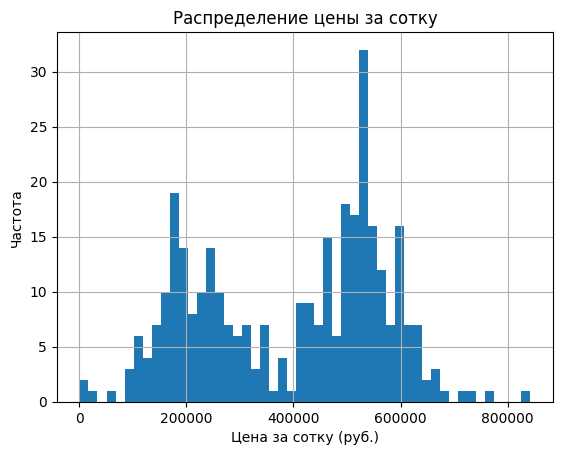

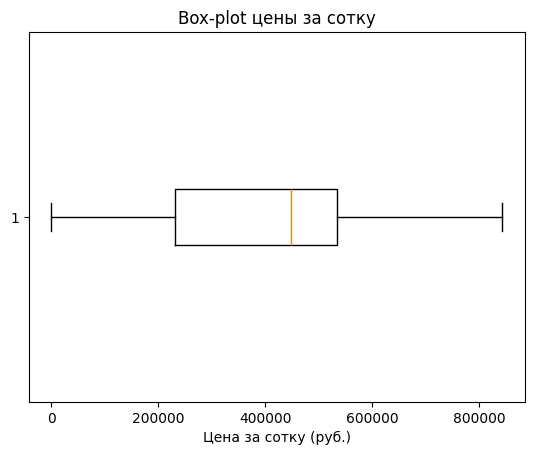

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# 1) Цена за сотку (100 м²)
blocks_pred["land_value_per_100m2"] = blocks_pred["land_value"] / blocks_pred["site_area"] * 100

# 2) Заменяем inf на NaN
blocks_pred = blocks_pred.replace([np.inf, -np.inf], np.nan)
blocks_pred = blocks_pred.fillna(0)

# 3) Удаляем выбросы: оставляем данные до 99-го перцентиля
p99 = blocks_pred["land_value_per_100m2"].quantile(0.95)
blocks_clean = blocks_pred[blocks_pred["land_value_per_100m2"] <= p99].copy()

print(blocks_clean["land_value_per_100m2"].describe())

# 4) Гистограмма после очистки
plt.figure()
blocks_clean["land_value_per_100m2"].dropna().hist(bins=50)
plt.xlabel("Цена за сотку (руб.)")
plt.ylabel("Частота")
plt.title("Распределение цены за сотку")
plt.show()



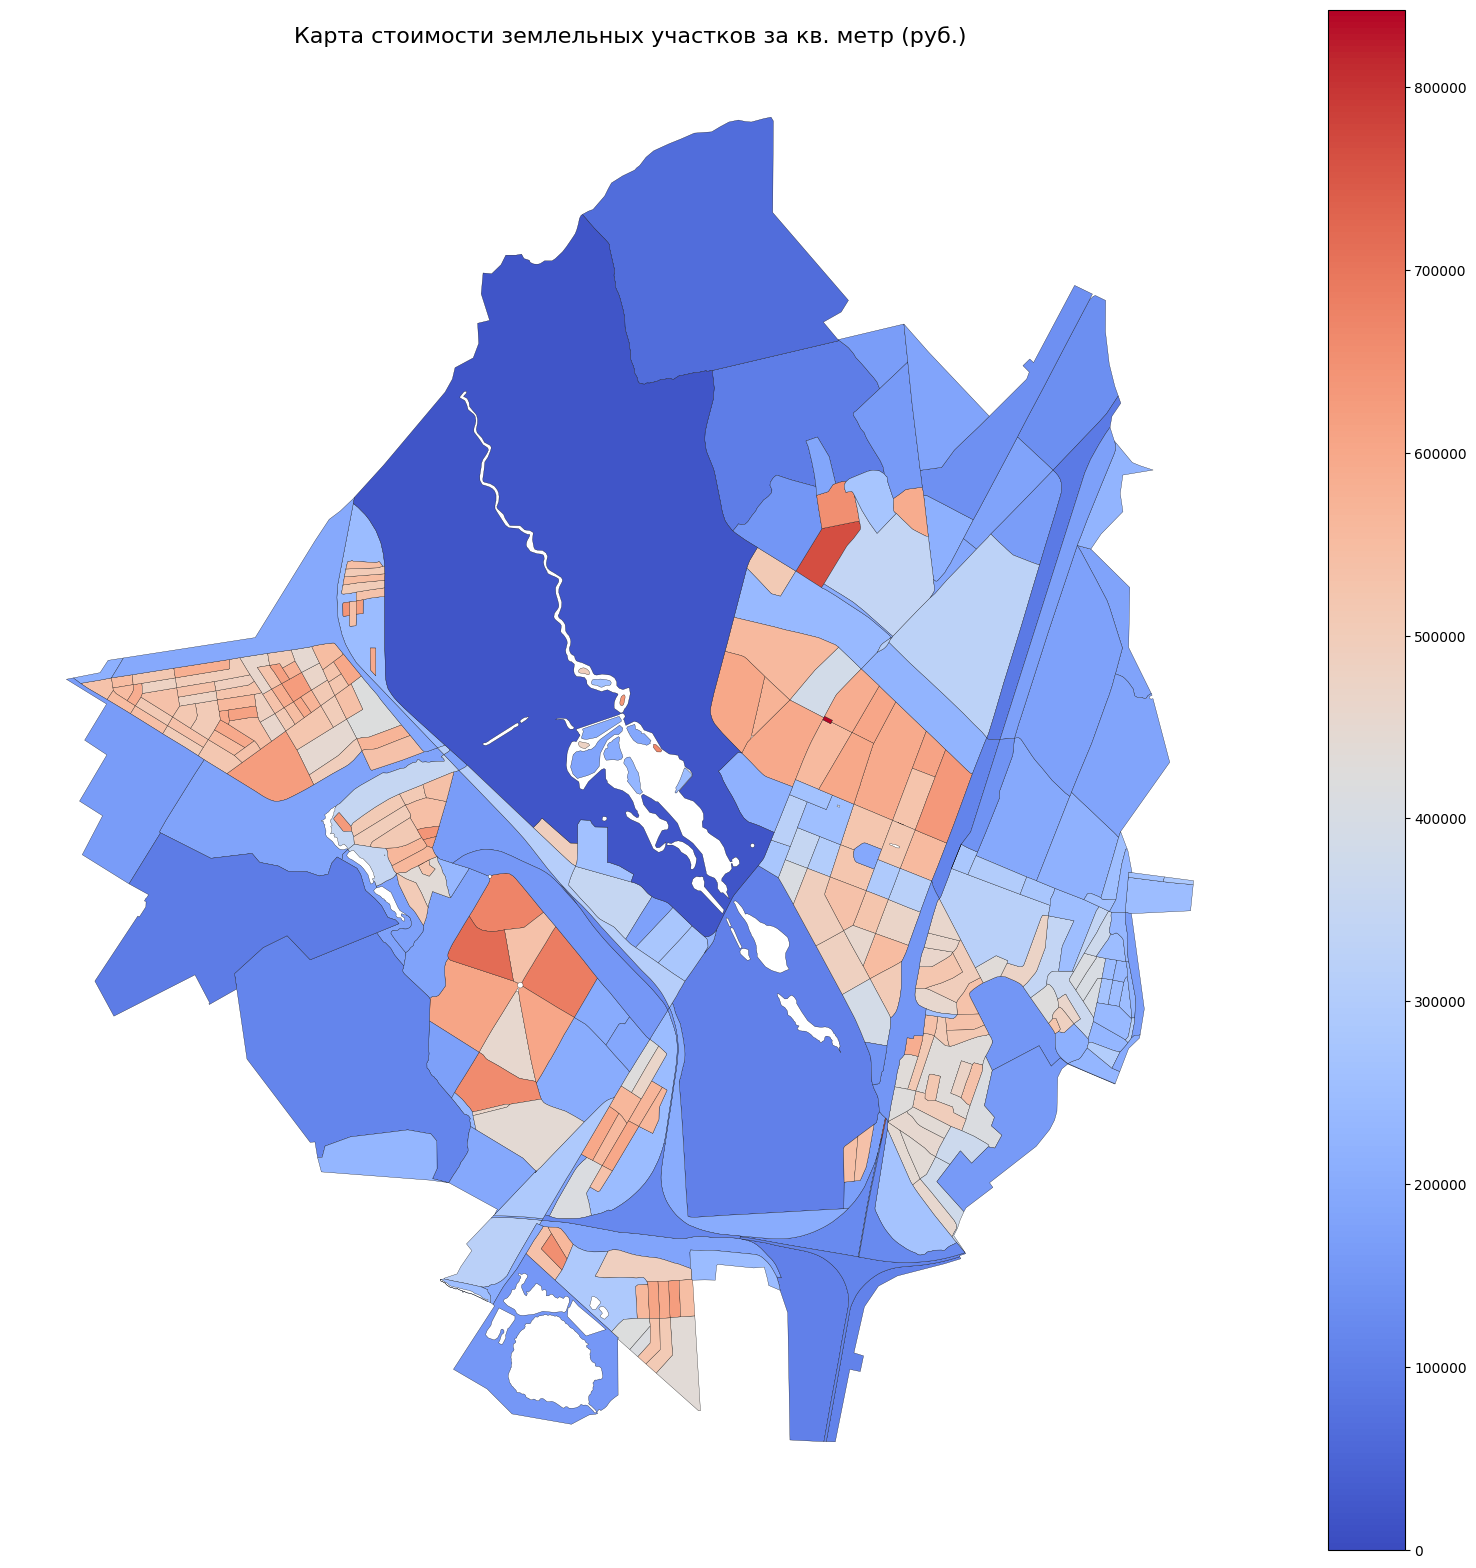

In [13]:
import matplotlib.pyplot as plt

blocks_clean.plot(
    column='land_value_per_100m2',
    legend=True,
    figsize=(20,20),
    cmap='coolwarm',
    edgecolor='black',   # <-- цвет границы
    linewidth=0.2        # <-- толщина границы
).set_axis_off()
plt.title('Карта стоимости землельных участков за кв. метр (руб.)', fontsize=16)

plt.show()

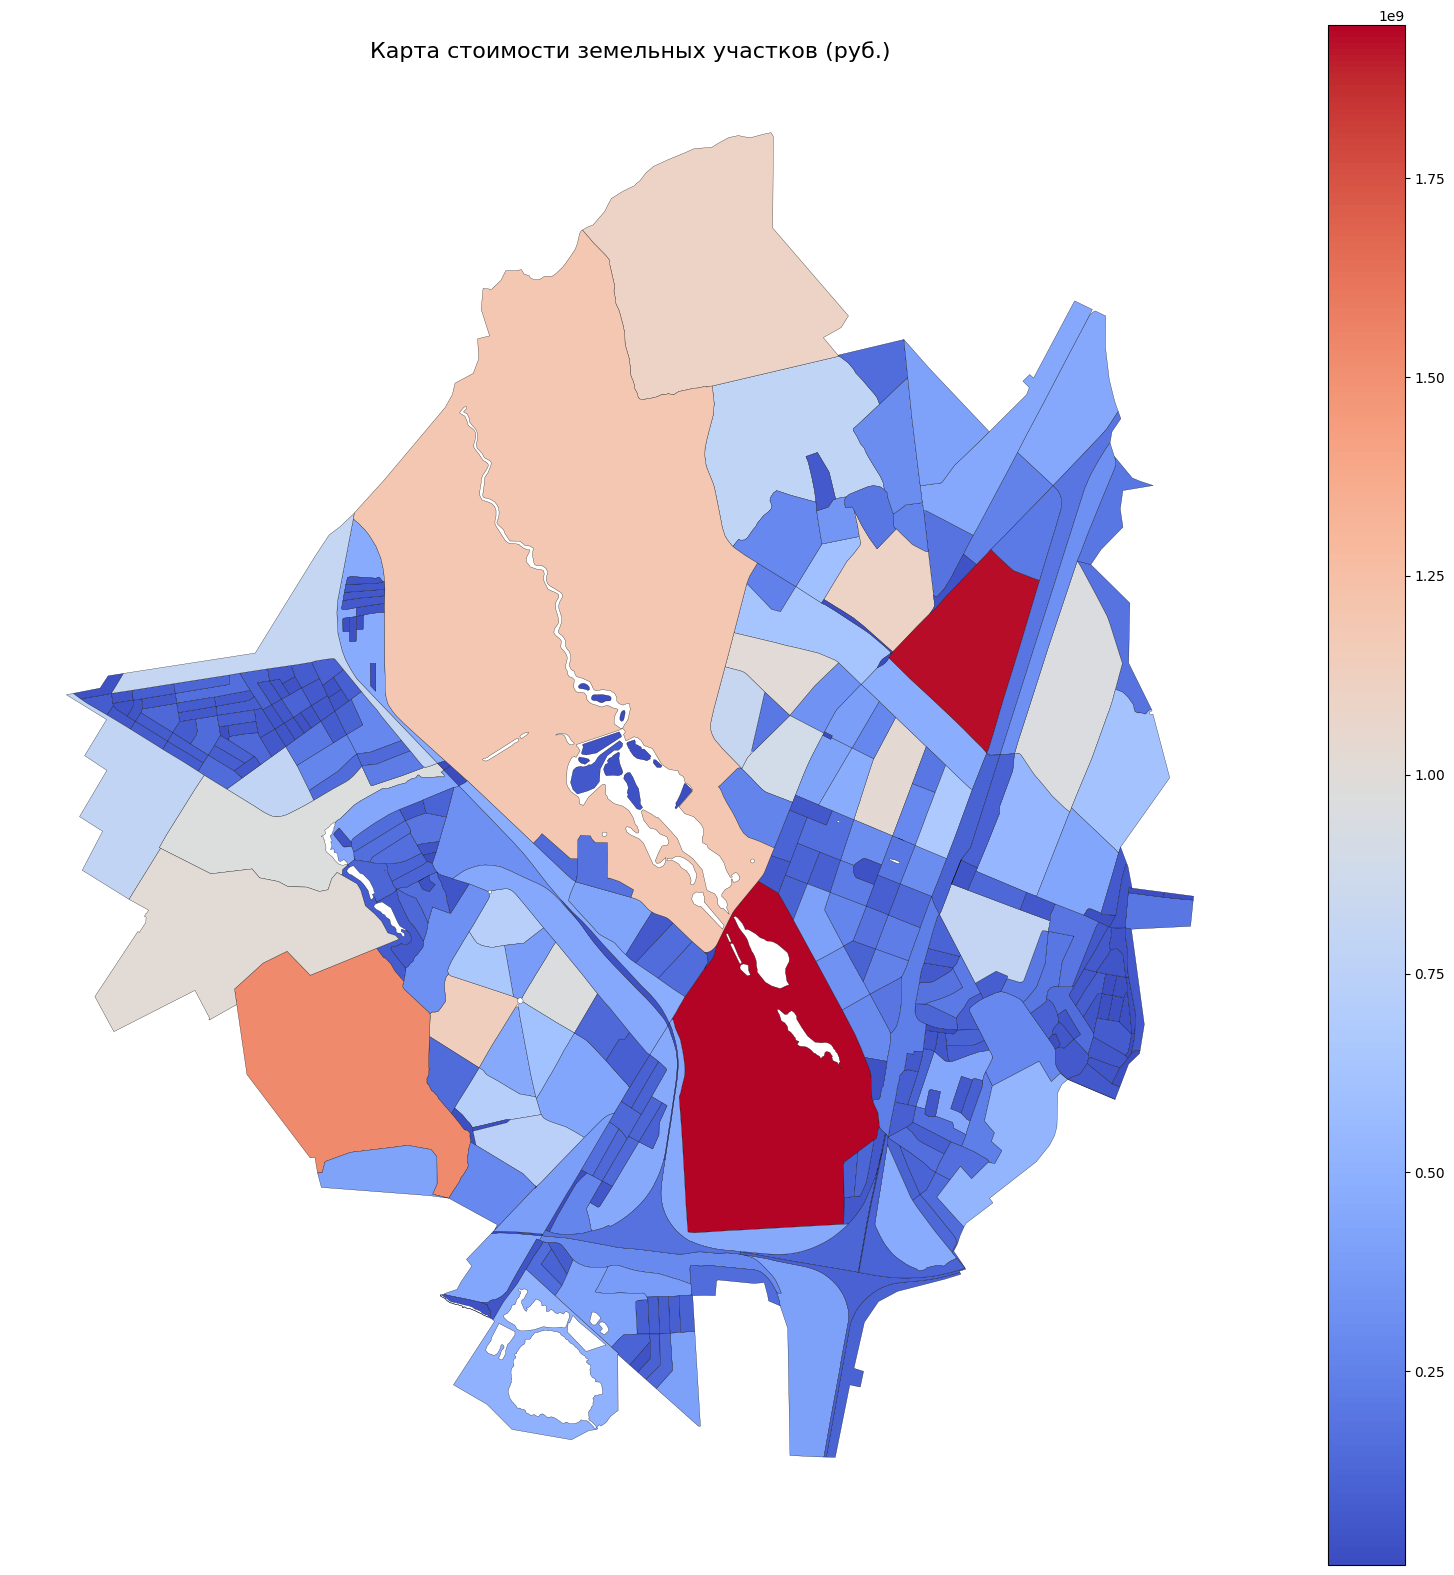

In [14]:
import matplotlib.pyplot as plt

blocks_clean.plot(
    column='land_value',
    legend=True,
    figsize=(20,20),
    cmap='coolwarm',
    edgecolor='black',   # <-- цвет границы
    linewidth=0.2        # <-- толщина границы
).set_axis_off()
plt.title('Карта стоимости земельных участков (руб.)', fontsize=16)

plt.show()

In [11]:
blocks_clean["id"] = blocks_clean.index

In [13]:
# blocks_clean.to_file("./data/blocks_clean_gatchina.geojson", driver="GeoJSON")

/tmp/ipykernel_188300/3388054100.py:8: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  blocks_clean.loc[blocks_clean["id"]==86].centroid.plot(


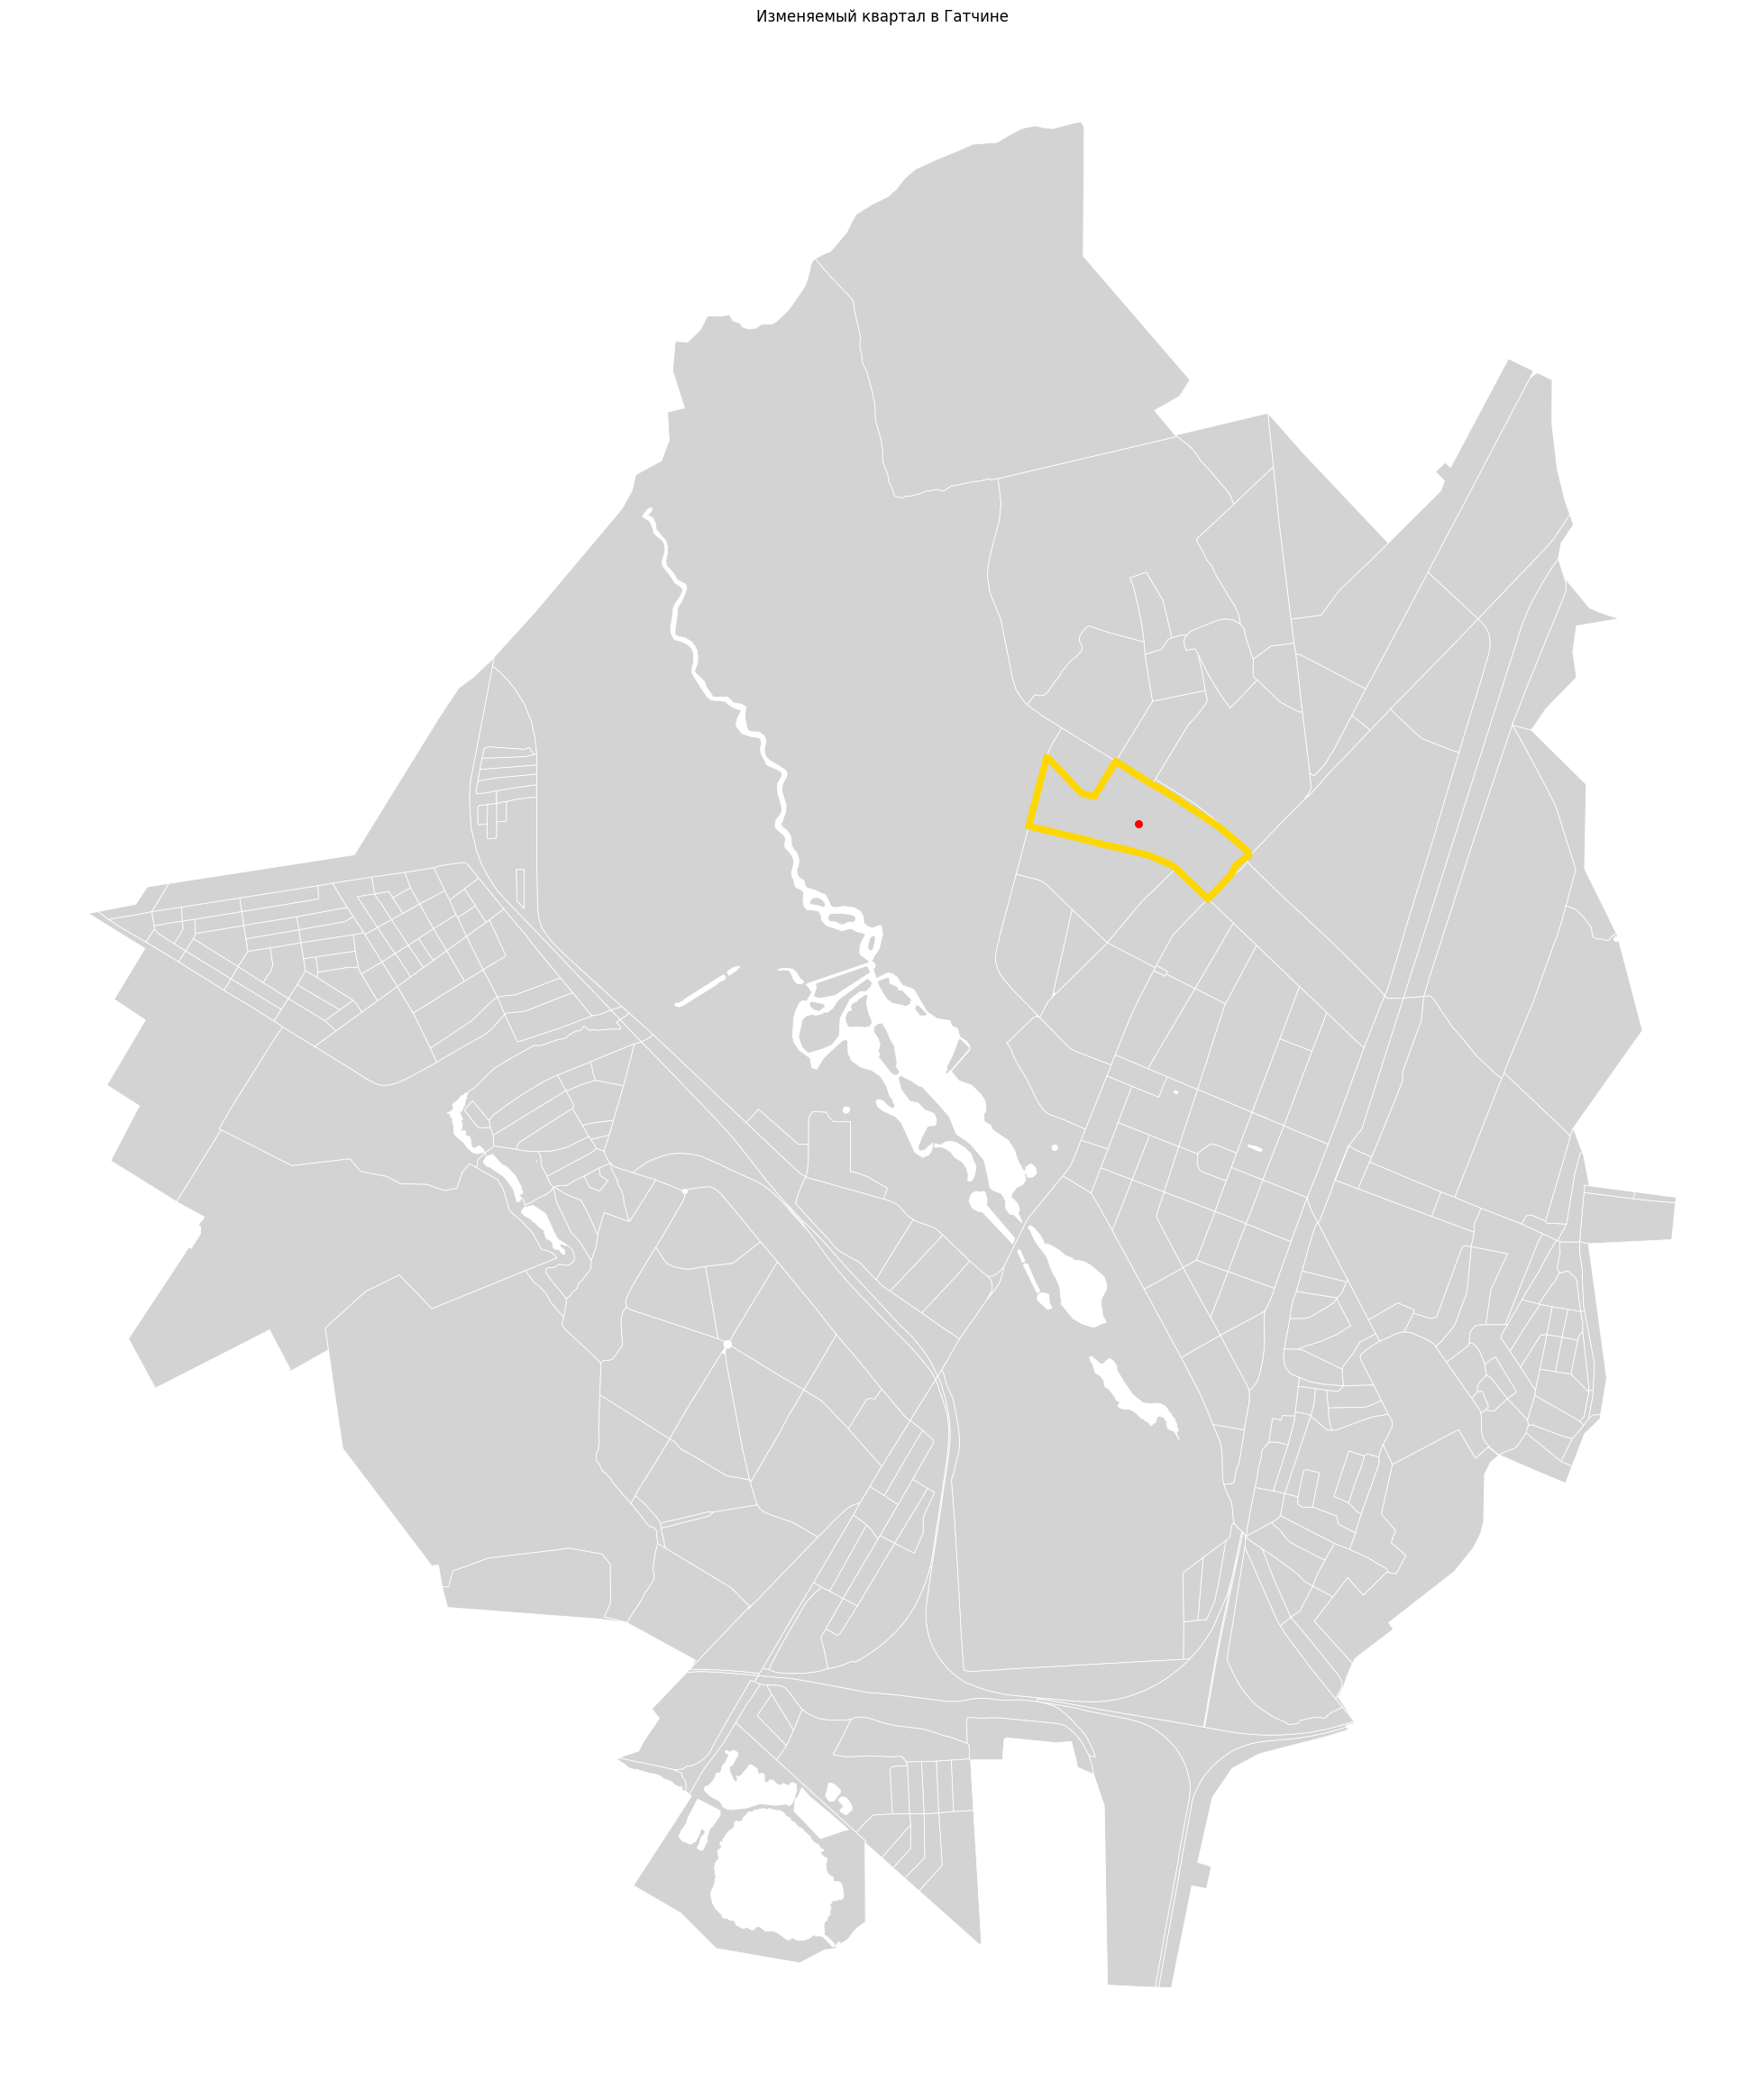

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(25, 35))
blocks_clean.plot(ax=ax, color="lightgrey", edgecolor="white", linewidth=0.6)  # фон
blocks_clean.loc[blocks_clean["id"]==86].plot(
    ax=ax, color="none", edgecolor="gold", linewidth=5.5
)
blocks_clean.loc[blocks_clean["id"]==86].centroid.plot(
     ax=ax, color="red", markersize=30, zorder=3
 )

ax.set_title("Изменяемый квартал в Гатчине")
ax.axis("off")
plt.show()

In [13]:
target_idx = 86

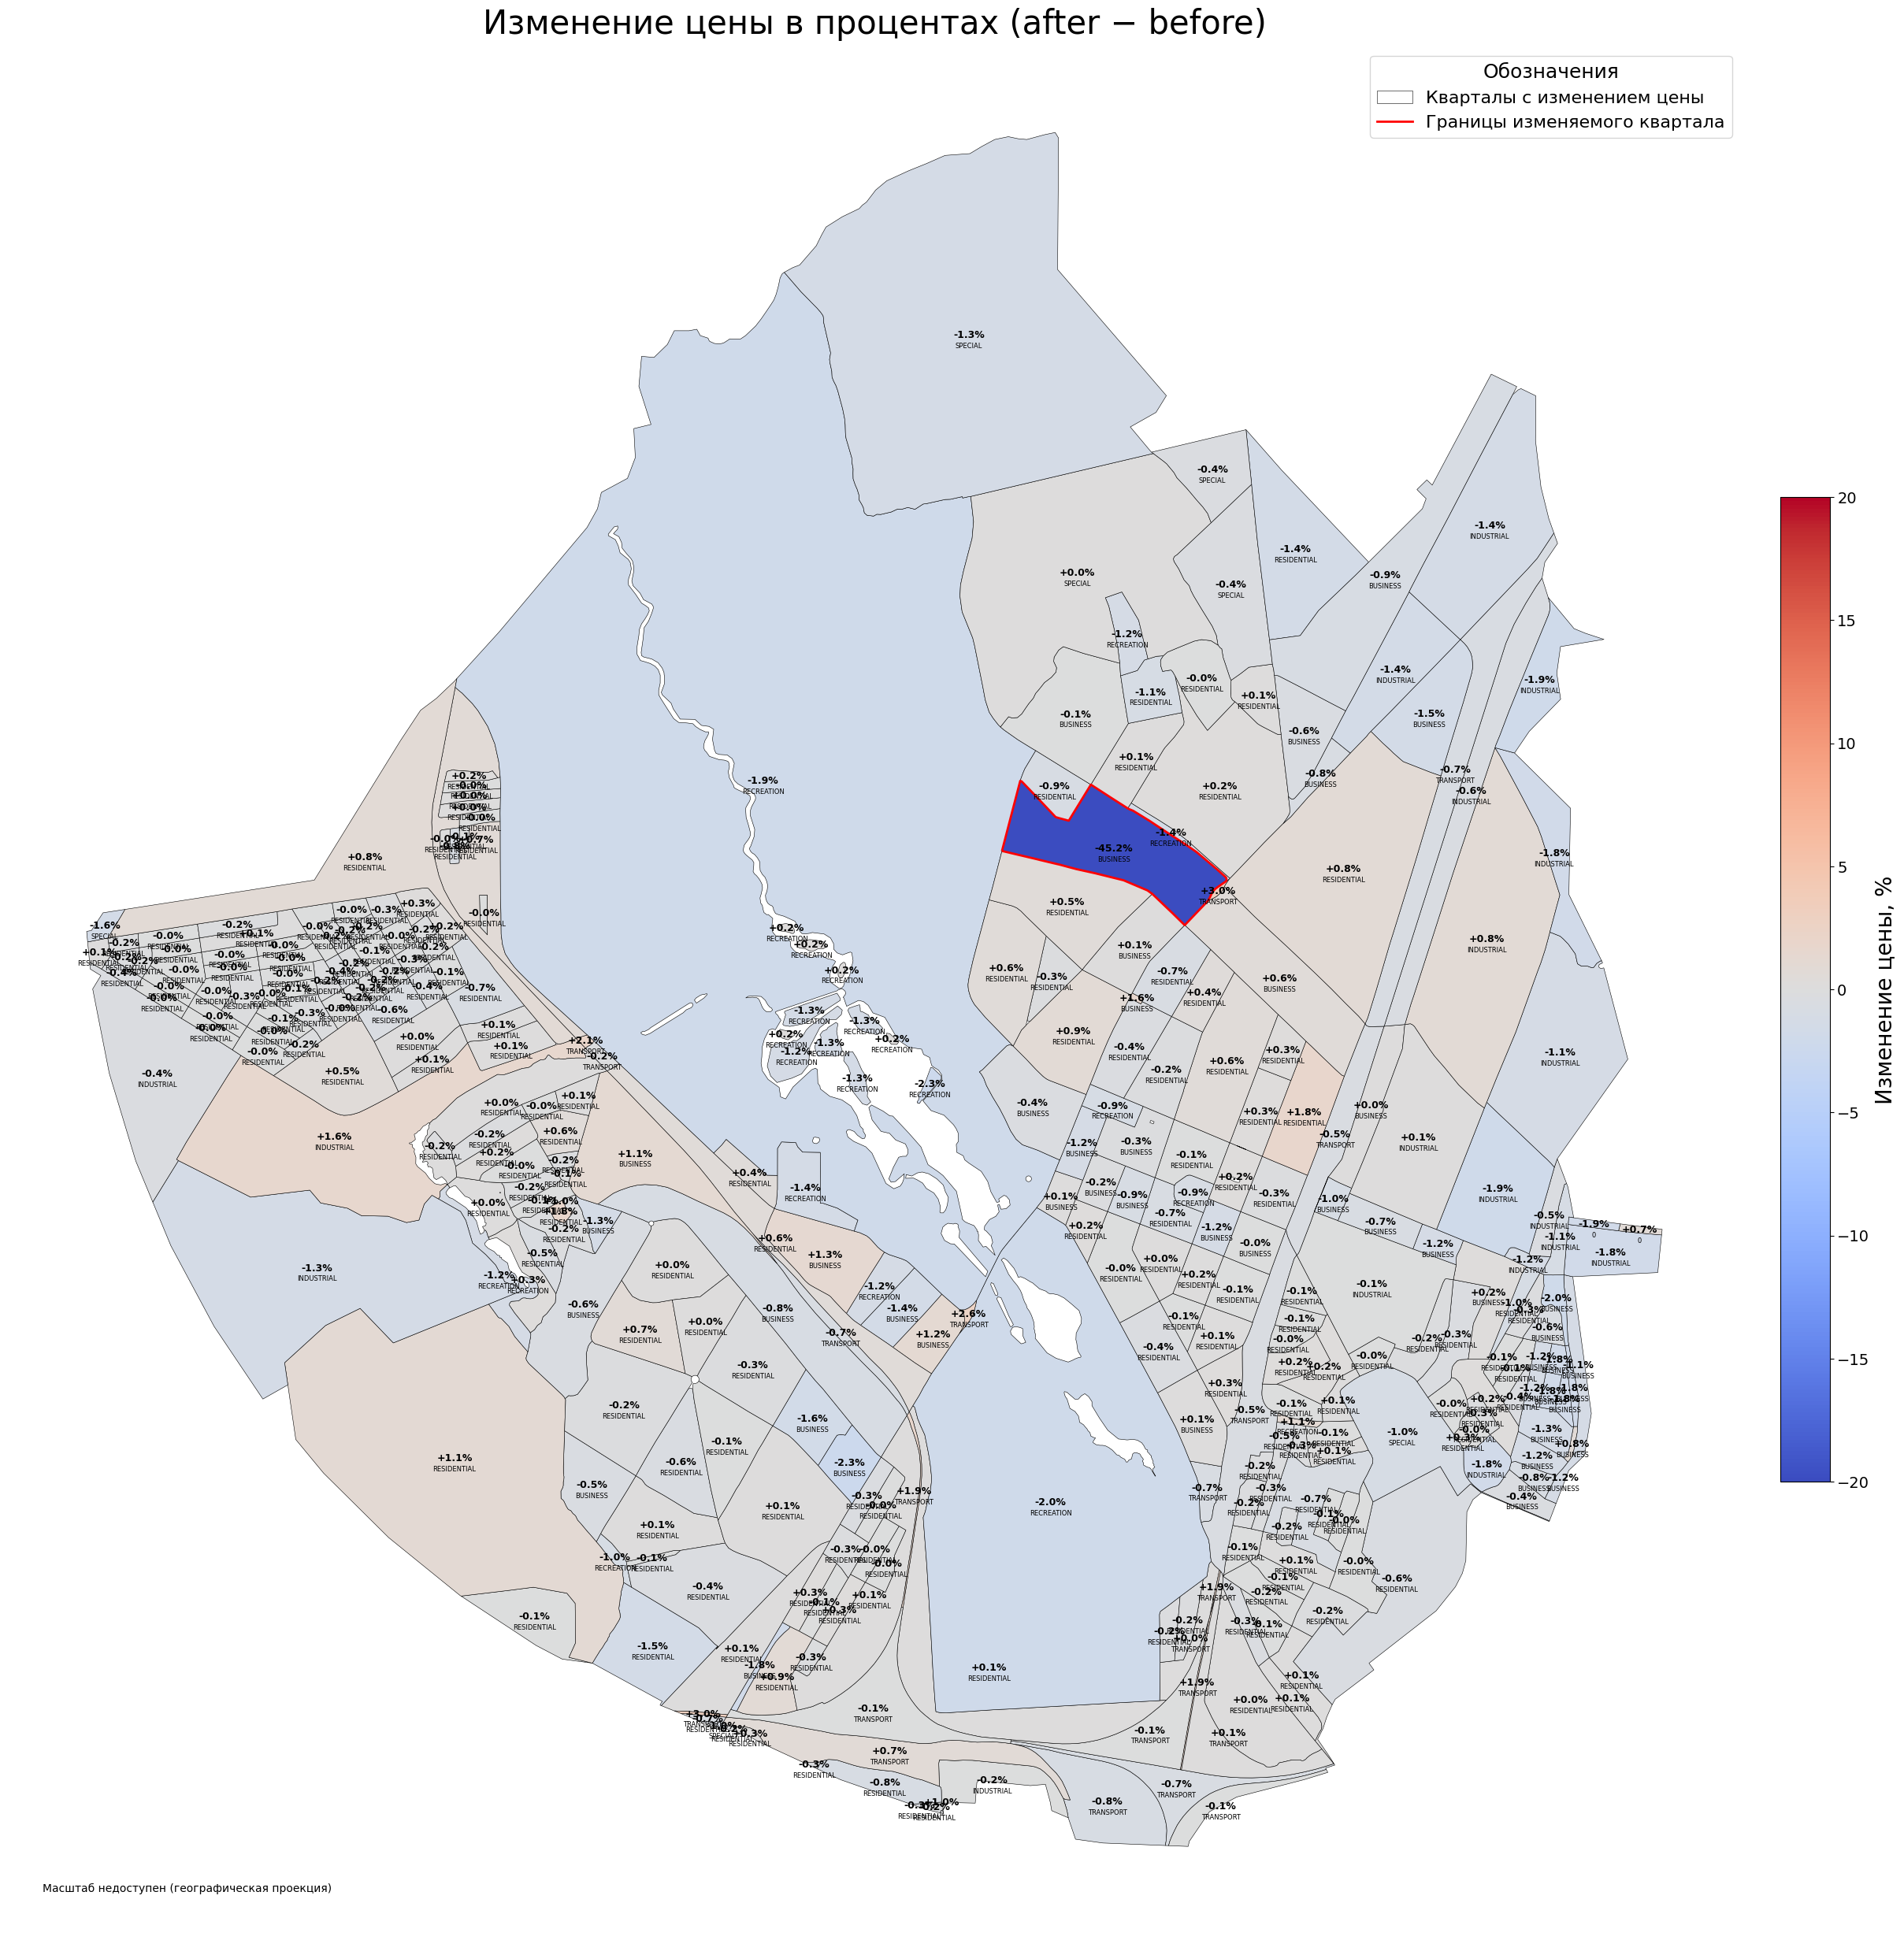


Статистика по кварталам в контексте (|Δ₽| > 1e-09):

Изменяемый квартал:
index | land_use | до (₽) → после (₽) | Δ₽ | Δ%
84 | BUSINESS | 623 308 644 ₽ → 341 500 173 ₽ | -281 808 470 ₽ | -45.2%

Кварталы в границах проекта:
Нет кварталов проекта с изменениями выше порога.

Кварталы в контексте:
index | land_use | до (₽) → после (₽) | Δ₽ | Δ%
231 | TRANSPORT | 401 645 295 ₽ → 398 431 585 ₽ | -3 213 710 ₽ | -0.8%
280 | TRANSPORT | 91 062 313 ₽ → 90 444 196 ₽ | -618 117 ₽ | -0.7%
299 | RESIDENTIAL | 93 537 890 ₽ → 93 364 223 ₽ | -173 668 ₽ | -0.2%
294 | 0 | 9 106 776 ₽ → 9 195 710 ₽ | +88 934 ₽ | +1.0%
300 | INDUSTRIAL | 140 378 880 ₽ → 140 161 072 ₽ | -217 808 ₽ | -0.2%
217 | TRANSPORT | 113 981 264 ₽ → 113 873 920 ₽ | -107 344 ₽ | -0.1%
281 | TRANSPORT | 6 911 378 ₽ → 7 040 619 ₽ | +129 240 ₽ | +1.9%
5 | TRANSPORT | 60 928 873 ₽ → 60 943 973 ₽ | +15 100 ₽ | +0.0%
111 | RESIDENTIAL | 88 959 178 ₽ → 88 776 298 ₽ | -182 879 ₽ | -0.2%
218 | TRANSPORT | 98 805 915 ₽ → 98 723 752 ₽ | -82 163 

In [14]:
from urbanomy.methods.land_value_modeling import (
    ScenarioTEPModifier,
    plot_scenario_impact,
    transfer_baseline_prices,
)

# Все снесли - ничего не осталось
blocks_after = blocks_clean.copy()
changes = {
        # Структура использования территории
        "residential": 0.0,
        "business": 0.0,
        "recreation": 0.0,
        "industrial": 0.0,
        "transport": 0.0,
        "special": 0.0,
        "agriculture": 0.0,
        "share": 1.0,

    
    "footprint_area": 0.0,   
    "build_floor_area": 0.0,  
    "living_area": 0.0,      
    "non_living_area": 0.0,  
    "population": 0.0,                

    
    "fsi": 0.0,                         
    "gsi": 0.0,                        
    "l": 0.0,                          
                    

        
        "morphotype": "low-rise non-residential",
}



modifier = ScenarioTEPModifier(blocks_after)
blocks_before = modifier.apply(target_idx, changes)

# 1) Предсказание стоимости до/после
before_estimator = LandPriceEstimator(model=model, blocks=blocks_before, use_service_features=False,)
after_estimator = LandPriceEstimator(model=model, blocks=blocks_after, use_service_features=False,)

blocks_before_pred = before_estimator.predict()
blocks_before_pred["land_value_per_100m2"] = blocks_before_pred["land_value"] / blocks_before_pred["site_area"] * 100

blocks_after_pred = after_estimator.predict()
blocks_after_pred["land_value_per_100m2"] = blocks_after_pred["land_value"] / blocks_after_pred["site_area"] * 100

blocks_full_value = transfer_baseline_prices(
    after_blocks=blocks_before_pred,
    before_blocks=blocks_after_pred,
    scenario_mode=False,
)

blocks_full_value = blocks_full_value.replace([np.inf, -np.inf], np.nan)
blocks_full_value = blocks_full_value.fillna(0)

# 3) Только визуализация и статистика по процентным изменениям
scenario_result = plot_scenario_impact(
    blocks=blocks_full_value,
    target_idx=target_idx,          
    target_id_column="id",   # если колонка называется иначе — укажи здесь
    figsize=(25, 35),
)

In [18]:
# blocks_after.to_file('./data/test/gatchina_RESIDENTIAL.geojson', driver='GeoJSON')

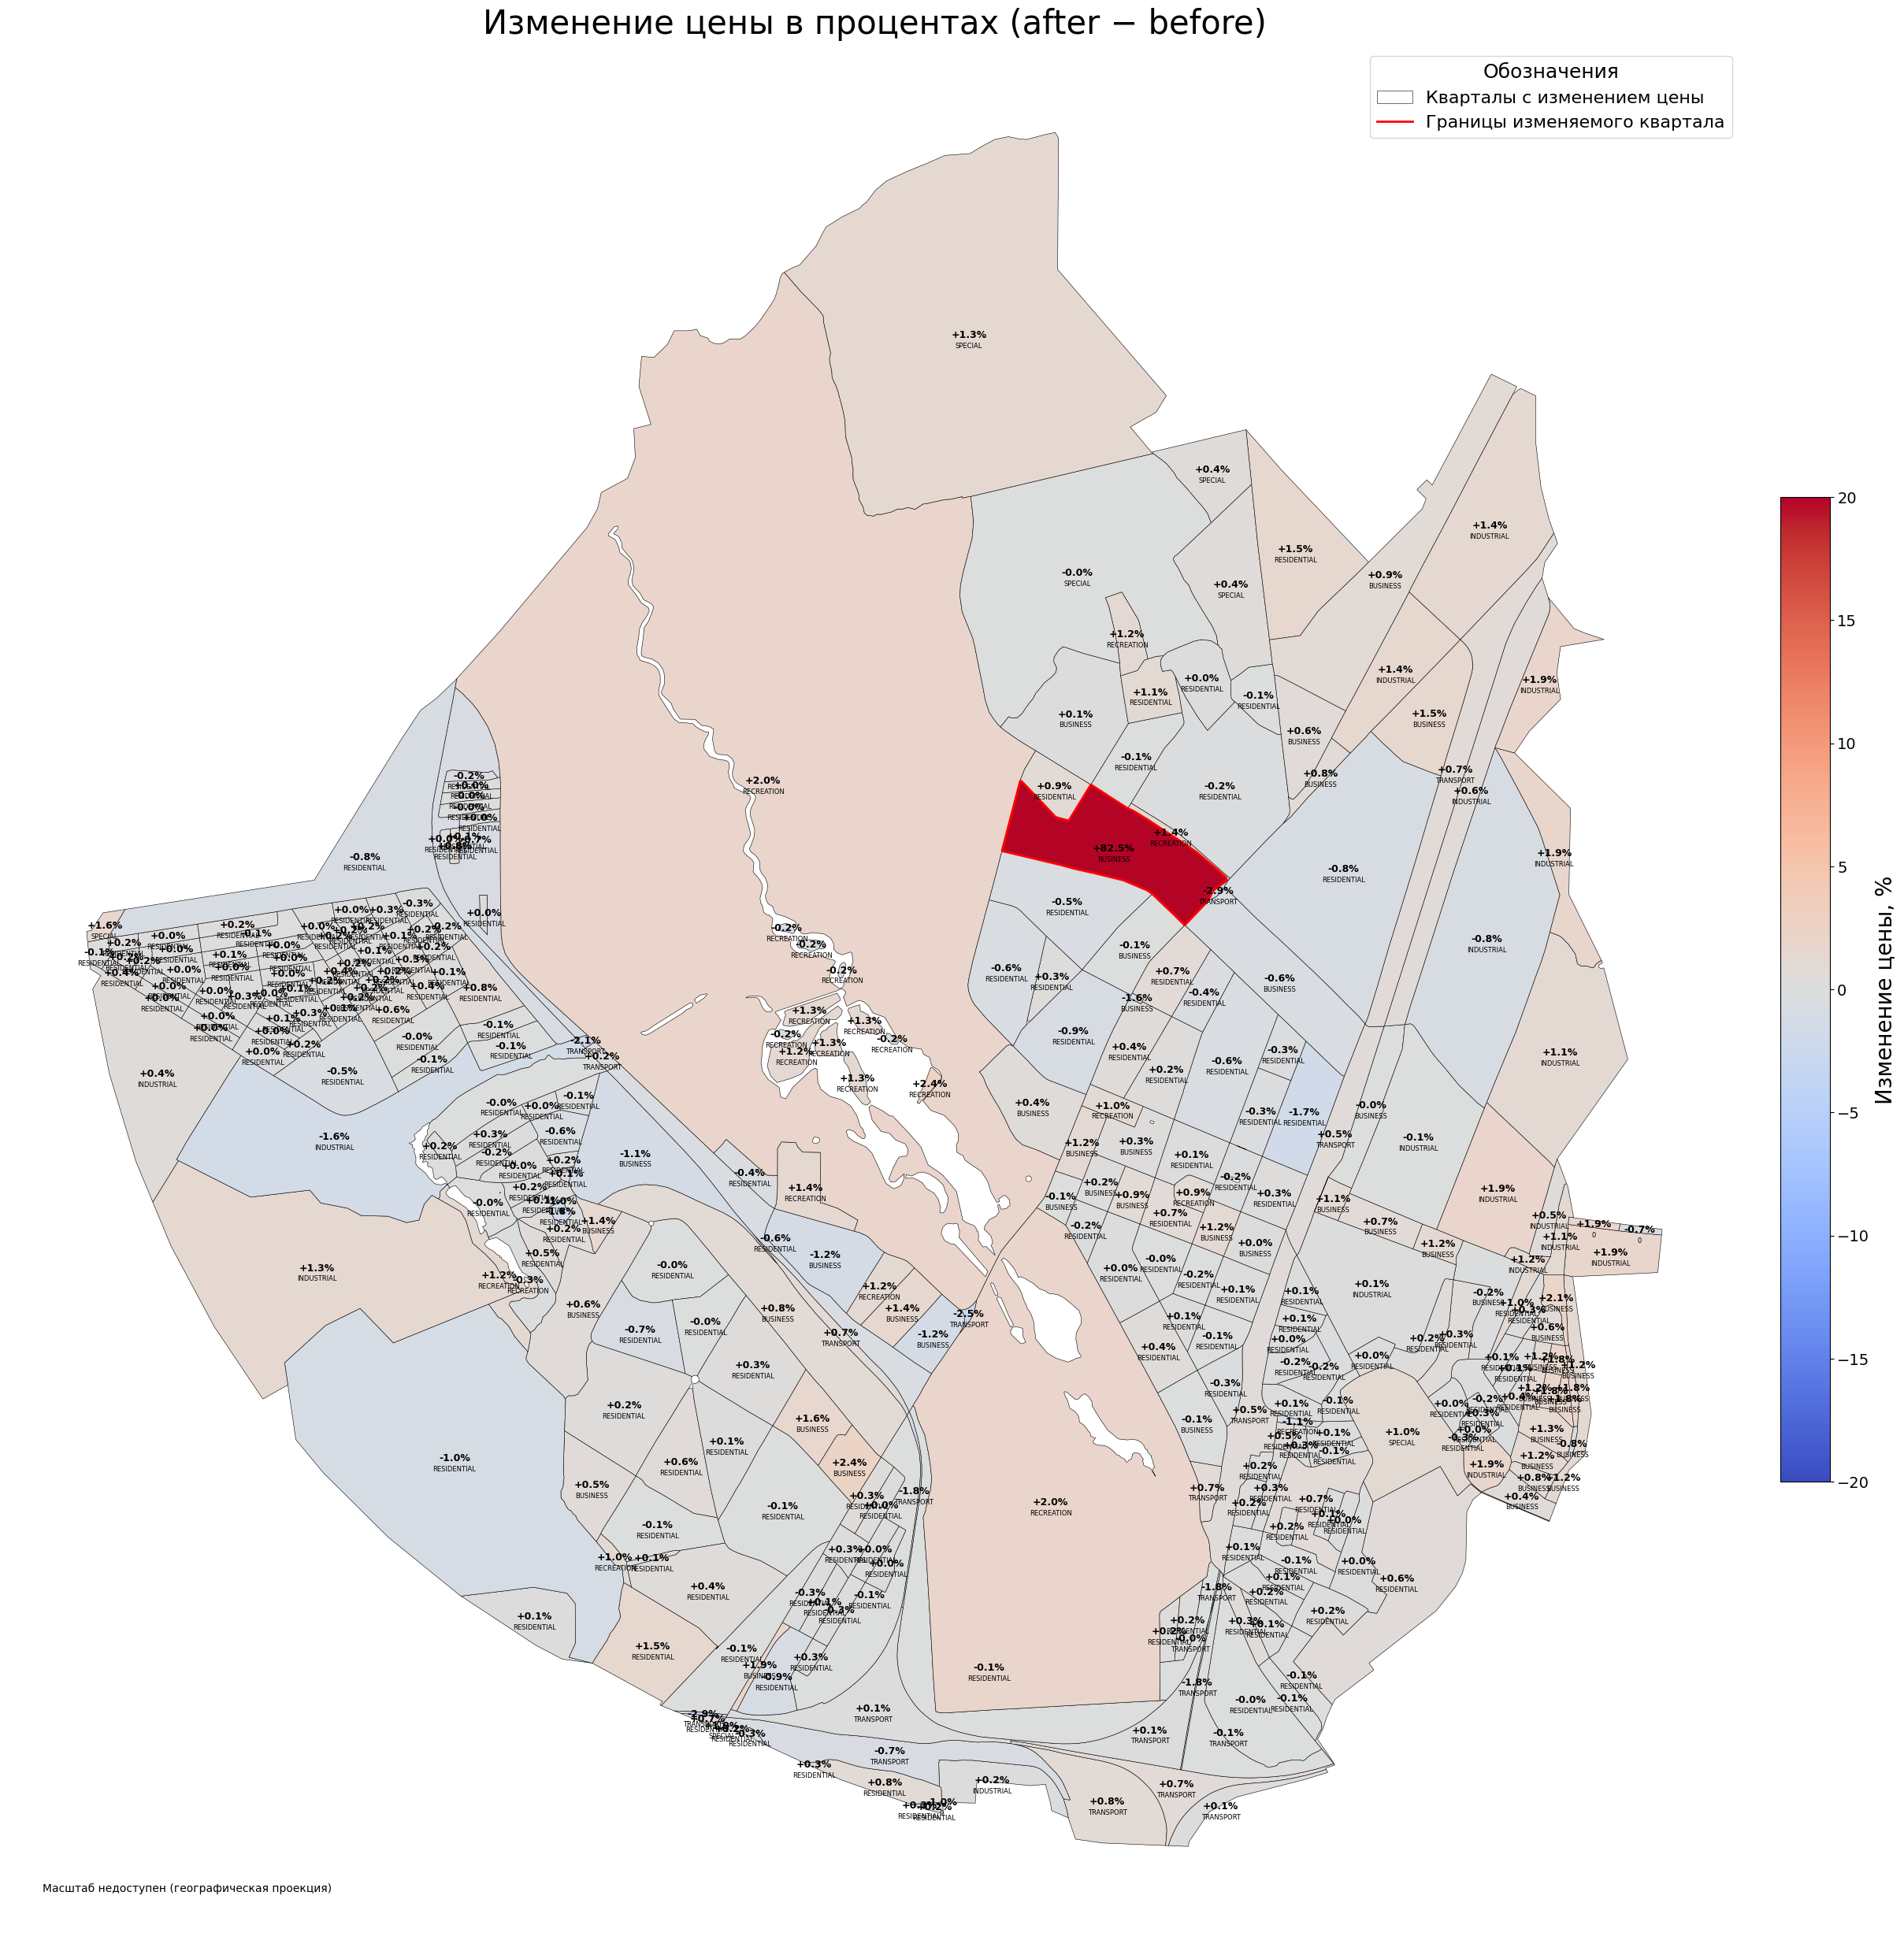


Статистика по кварталам в контексте (|Δ₽| > 1e-09):

Изменяемый квартал:
index | land_use | до (₽) → после (₽) | Δ₽ | Δ%
84 | BUSINESS | 341 500 173 ₽ → 623 308 644 ₽ | +281 808 470 ₽ | +82.5%

Кварталы в границах проекта:
Нет кварталов проекта с изменениями выше порога.

Кварталы в контексте:
index | land_use | до (₽) → после (₽) | Δ₽ | Δ%
231 | TRANSPORT | 398 431 585 ₽ → 401 645 295 ₽ | +3 213 710 ₽ | +0.8%
280 | TRANSPORT | 90 444 196 ₽ → 91 062 313 ₽ | +618 117 ₽ | +0.7%
299 | RESIDENTIAL | 93 364 223 ₽ → 93 537 890 ₽ | +173 668 ₽ | +0.2%
294 | 0 | 9 195 710 ₽ → 9 106 776 ₽ | -88 934 ₽ | -1.0%
300 | INDUSTRIAL | 140 161 072 ₽ → 140 378 880 ₽ | +217 808 ₽ | +0.2%
217 | TRANSPORT | 113 873 920 ₽ → 113 981 264 ₽ | +107 344 ₽ | +0.1%
281 | TRANSPORT | 7 040 619 ₽ → 6 911 378 ₽ | -129 240 ₽ | -1.8%
5 | TRANSPORT | 60 943 973 ₽ → 60 928 873 ₽ | -15 100 ₽ | -0.0%
111 | RESIDENTIAL | 88 776 298 ₽ → 88 959 178 ₽ | +182 879 ₽ | +0.2%
218 | TRANSPORT | 98 723 752 ₽ → 98 805 915 ₽ | +82 163 

In [15]:
blocks_full_value = transfer_baseline_prices(
    after_blocks=blocks_after_pred,
    before_blocks=blocks_before_pred,
    scenario_mode=False,
)

blocks_full_value = blocks_full_value.replace([np.inf, -np.inf], np.nan)
blocks_full_value = blocks_full_value.fillna(0)

# 3) Только визуализация и статистика по процентным изменениям
scenario_result = plot_scenario_impact(
    blocks=blocks_full_value,
    target_idx=target_idx,          
    target_id_column="id",   # если колонка называется иначе — укажи здесь
    figsize=(25, 35),
)

# **Инвестиционная** привлекактельтность 

In [19]:
blocks_after = blocks_after.copy()
blocks_after["is_project"] = False
blocks_after.loc[blocks_after["id"] == target_idx, "is_project"] = True


In [19]:
from blocksnet.enums import LandUse

benchmarks_ru = {
    LandUse.RESIDENTIAL: {
        "cost_build": 45_000,
        "price_sale": 140_000,
        "construction_years": 3,
        "sale_years": 4,
        "opex_rate": 800,
        "cost_demolition": 900,  # ₽/м² ориентировочно по России
    },
    LandUse.BUSINESS: {
        "cost_build": 55_000,
        "rent_annual": 25_000,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 1_300,
        "cost_demolition": 900,
    },
    LandUse.RECREATION: {
        "cost_build": 20_000,
        "rent_annual": 7_500,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 1_000,
        "cost_demolition": 900,
    },
    LandUse.SPECIAL: {
        "cost_build": 35_000,
        "rent_annual": 11_000,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 1_500,
        "cost_demolition": 900,
    },
    LandUse.INDUSTRIAL: {
        "cost_build": 38_000,
        "rent_annual": 14_800,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 700,
        "cost_demolition": 900,
    },
    LandUse.AGRICULTURE: {
        "cost_build": 25_000,
        "rent_annual": 6_500,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 300,
        "cost_demolition": 900,
    },
    LandUse.TRANSPORT: {
        "cost_build": 18_000,
        "rent_annual": 8_200,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 600,
        "cost_demolition": 900,
    },
}


In [20]:
from urbanomy.methods.investment_potential import prepare_investment_input

investment_input = prepare_investment_input(
    gdf = blocks_after,
)

investment_input.head()

2026-03-10 19:04:50.759 | WARNING  | urbanomy.utils.investment_input:prepare_investment_input:265 - prepare_investment_input: колонка 'land_value_before' не найдена; значения скопированы из 'land_value'.


,land_use,land_value,land_value_before,residential,business,recreation,industrial,transport,special,agriculture,site_area,living_area,non_living_area,build_floor_area,share
0,LandUse.BUSINESS,6.291669e+08,6.291669e+08,70405.906896,170016.485982,17274.763974,0.0,4560.664101,0.0,0.0,262250.979778,44241.785252,62865.904925,107107.690178,0.648297


In [24]:
from urbanomy.methods.investment_potential import InvestmentAttractivenessAnalyzer

an = InvestmentAttractivenessAnalyzer(benchmarks=benchmarks_ru)
summary = an.calculate_investment_metrics(investment_input, discount_rate=0.18)
summary

Project totals:
 • Land area:          262,257.82
 • Built area:         107,107.69
 • Land value:         629,166,893.77
 • Demolition cost:    96,396,921.16
 • Construction cost:  5,287,535,485.09
 • Investment need:    6,013,099,300.02
 • Project NPV:        665,568,118.81
 • Project IRR:        0.21
 • Project PI:         1.13
 • Project PP (yrs):   11.66


,land_use,land_area,land_value_before,built_area,land_value,demolition_cost,construction_cost,investment_need,NPV,IRR,PI,PP_years,EI
0,LandUse.BUSINESS,262257.82,6.291669e+08,107107.69,6.291669e+08,96396921.16,5.287535e+09,6.013099e+09,6.655681e+08,0.21,1.13,11.66,61.19


In [25]:
from urbanomy.methods.socio_economic_indicators.sei_calculate import SEREstimator

deafaut_cfg = {
    "population": 91_000,
}

est = SEREstimator(deafaut_cfg) # or use project_cfg
result = est.compute(scn, pretty=True)
result

,indicator,delta_total
0,Объём инвестиций в основной капитал на душу на...,58 105
1,Валовый региональный продукт на душу населения,43 176
2,Доходы бюджета территории,1 145 608 723
3,Средний уровень заработной платы,1 390
4,Износ основного фонда (тыс. руб.),150 695


## Оптимизация пустого района

In [17]:
from urbanomy.methods.land_value_modeling.ga_mc_optimizer import DistrictProblem
# теперь оптимизируем пустой район генетикой!
target_idx = 86
site_area = float(blocks_clean["site_area"].iloc[86])


In [20]:
problem = DistrictProblem(
    blocks=blocks_clean,
    target_idx=target_idx,
    model=model,
    benchmarks=benchmarks_ru,
    
constraints = {
    "footprint_area": {"type": "float", "min": 0.0, "max": 0.1 * site_area},
    "l": {"type": "float", "min": 1.0, "max": 10.0},
    "mxi": {"type": "float", "min": 0.0, "max": 1.0},

    "residential": {"type": "float", "min": 0.0, "max": 1.0},
    "business": {"type": "float", "min": 0.0, "max": 1.0},
    "recreation": {"type": "float", "min": 0.0, "max": 1.0},
    "industrial": {"type": "float", "min": 0.0, "max": 1.0},
    "transport": {"type": "float", "min": 0.0, "max": 1.0},
    "special": {"type": "float", "min": 0.0, "max": 1.0},
    "agriculture": {"type": "float", "min": 0.0, "max": 1.0},
},
    
    estimator_kwargs={
        "orig_features": numeric_feats+cat_features,
        "categorical_features": cat_features,
    }
)

TypeError: DistrictProblem.__init__() missing 1 required positional argument: 'potential_df'

In [29]:
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize

algorithm = NSGA2(
    pop_size=15,
    eliminate_duplicates=True,
)

res = minimize(
    problem,
    algorithm,
    ('n_gen', 15),
    seed=42,
    verbose=True,
    save_history=True,
)


n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |       15 |      3 |             - |             -
     2 |       30 |      2 |  0.1177949436 |         ideal
     3 |       45 |      2 |  0.6404369350 |         ideal
     4 |       60 |      3 |  0.6572035836 |         ideal


KeyboardInterrupt: 

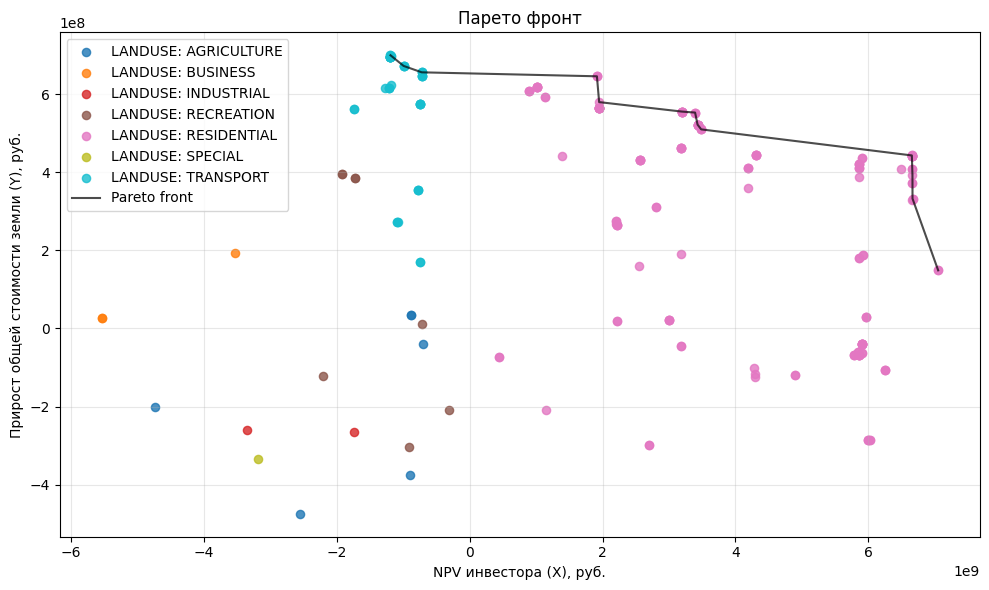

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

optimizer = problem

# 1) Базовая стоимость "до"
baseline_land_value = optimizer.evaluate_catboost(
    geonome=optimizer.blocks,
    model=optimizer.model,
    orig_features=optimizer.estimator_kwargs["orig_features"],
    cat_features=optimizer.estimator_kwargs["categorical_features"],
    radius_list=None,
)

# 2) Собираем ВСЕ решения: из history (если optimize(..., save_history=True)), иначе из res.X/res.F
X_all, F_all = [], []
if getattr(res, "history", None):
    for alg in res.history:
        pop = alg.pop
        Xi, Fi = pop.get("X"), pop.get("F")
        if Xi is not None and Fi is not None and len(Xi):
            X_all.append(np.asarray(Xi))
            F_all.append(np.asarray(Fi))

if X_all:
    X = np.vstack(X_all)
    F = np.vstack(F_all)
else:
    X = np.asarray(res.X)
    F = np.asarray(res.F)

# 3) Цели
land_value_total = -F[:, 0]
admin_gain = land_value_total - baseline_land_value
investor_npv = -F[:, 1]

# 4) LANDUSE для каждого решения (через тот же repair, что в оптимизаторе)
landuse_labels = []
for genome_vec in X:
    changes = {name: genome_vec[j] for j, name in enumerate(optimizer.var_names)}
    repaired = optimizer._repair_genome(changes)   # использует логику из вашей задачи
    lu = repaired["land_use"]
    lu_name = getattr(lu, "name", str(lu).split(".")[-1])
    landuse_labels.append(lu_name)

landuse_labels = np.array(landuse_labels)
unique_lu = np.unique(landuse_labels)

# 5) Цвета + легенда
cmap = plt.get_cmap("tab10", len(unique_lu))
color_map = {lu: cmap(i) for i, lu in enumerate(unique_lu)}

plt.figure(figsize=(10, 6))

for lu in unique_lu:
    m = landuse_labels == lu
    plt.scatter(
        investor_npv[m],
        admin_gain[m],
        s=35,
        alpha=0.8,
        color=color_map[lu],
        label=f"LANDUSE: {lu}",
    )

# (опционально) поверх — линия самого Pareto-фронта из res.F
pf_x = -res.F[:, 1]
pf_y = -res.F[:, 0] - baseline_land_value
order = np.argsort(pf_x)
plt.plot(pf_x[order], pf_y[order], color="black", lw=1.5, alpha=0.7, label="Pareto front")

plt.xlabel("NPV инвестора (X), руб.")
plt.ylabel("Прирост общей стоимости земли (Y), руб.")
plt.title("Парето фронт")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()   


In [ ]:
print("Лучшие решения (переменные):\n", res.X) # Массив решений на фронте Парето
print("Значения целевых функций:\n", -res.F)


Лучшие решения (переменные):
 [[1.38237959e+04 5.40867669e+00 8.66284539e-01 2.37458225e-01
  8.46548135e-02 2.67105674e-01 2.93535910e-01 6.33794090e-01
  1.39769631e-01 1.75135051e-02]
 [3.22899883e+04 8.13541637e+00 2.65869961e-01 9.79839642e-01
  9.56965846e-02 7.35845321e-01 4.12296768e-01 6.30479813e-01
  1.39755187e-01 1.85015406e-02]
 [2.26515293e+04 5.88834893e+00 7.01443830e-01 9.68984663e-01
  7.90030004e-01 2.91045130e-01 3.69267504e-01 3.27484643e-01
  5.40647342e-01 4.48602627e-02]
 [3.13354321e+04 7.92422994e+00 2.65869961e-01 9.79917564e-01
  7.89132857e-01 7.01748364e-01 3.70883181e-01 6.65443722e-01
  1.00318621e-01 1.56103943e-02]
 [1.39530163e+04 5.48218517e+00 8.61040304e-01 9.97246598e-01
  8.64843690e-02 2.94864328e-01 2.93535910e-01 6.32205685e-01
  4.91873178e-01 2.46083767e-02]
 [3.12746818e+04 7.95188821e+00 4.19606012e-01 9.68984663e-01
  7.89134088e-01 3.08913783e-01 3.70885765e-01 3.27484643e-01
  5.35005118e-01 4.53786262e-02]
 [7.31693173e+03 5.41296347e

In [ ]:
len(res.opt)

15

In [ ]:
import numpy as np

# т.к. F минимизируется, а ты пишешь F[:,0] = -land_value
idx_city = np.argmin(res.F[:, 0])   # максимум land_value
params_optimal = {p: res.X[idx_city][i] for i, p in enumerate(problem.constraints.keys())}
params_optimal

{'footprint_area': np.float64(13823.79591733217),
 'l': np.float64(5.408676687308205),
 'mxi': np.float64(0.8662845394940122),
 'residential': np.float64(0.23745822525120286),
 'business': np.float64(0.08465481350154196),
 'recreation': np.float64(0.26710567363069004),
 'industrial': np.float64(0.2935359102422739),
 'transport': np.float64(0.6337940898629333),
 'special': np.float64(0.1397696314265124),
 'agriculture': np.float64(0.01751350510112277)}

In [ ]:
params_optimal = {param: res.X[3][i] for i, param in enumerate(problem.constraints.keys())}
params_optimal

{'footprint_area': np.float64(31335.43214925313),
 'l': np.float64(7.924229938600429),
 'mxi': np.float64(0.2658699614595196),
 'residential': np.float64(0.9799175637326438),
 'business': np.float64(0.7891328565906839),
 'recreation': np.float64(0.7017483643418121),
 'industrial': np.float64(0.3708831808016525),
 'transport': np.float64(0.6654437221317253),
 'special': np.float64(0.10031862102108419),
 'agriculture': np.float64(0.015610394306925221)}

In [ ]:
params_repaired = problem._repair_genome(params_optimal)
params_repaired

{'footprint_area': 31335.43214925313,
 'l': 7.924229938600429,
 'mxi': 0.2658699614595196,
 'residential': 0.2704672283697826,
 'business': 0.21780870599421553,
 'recreation': 0.1936896960940098,
 'industrial': 0.10236753546725946,
 'transport': 0.18366924506941953,
 'special': 0.027688961179650886,
 'agriculture': 0.004308627825662114,
 'share': 0.2704672283697826,
 'land_use': <LandUse.RESIDENTIAL: 'residential'>,
 'build_floor_area': 248309.16957609405,
 'living_area': 66017.94934524143,
 'non_living_area': 182291.2202308526,
 'population': 3300.8974672620716,
 'fsi': 0.7503497006191737,
 'gsi': 0.09469055118707216,
 'morphotype': 'mid-rise microdistrict'}

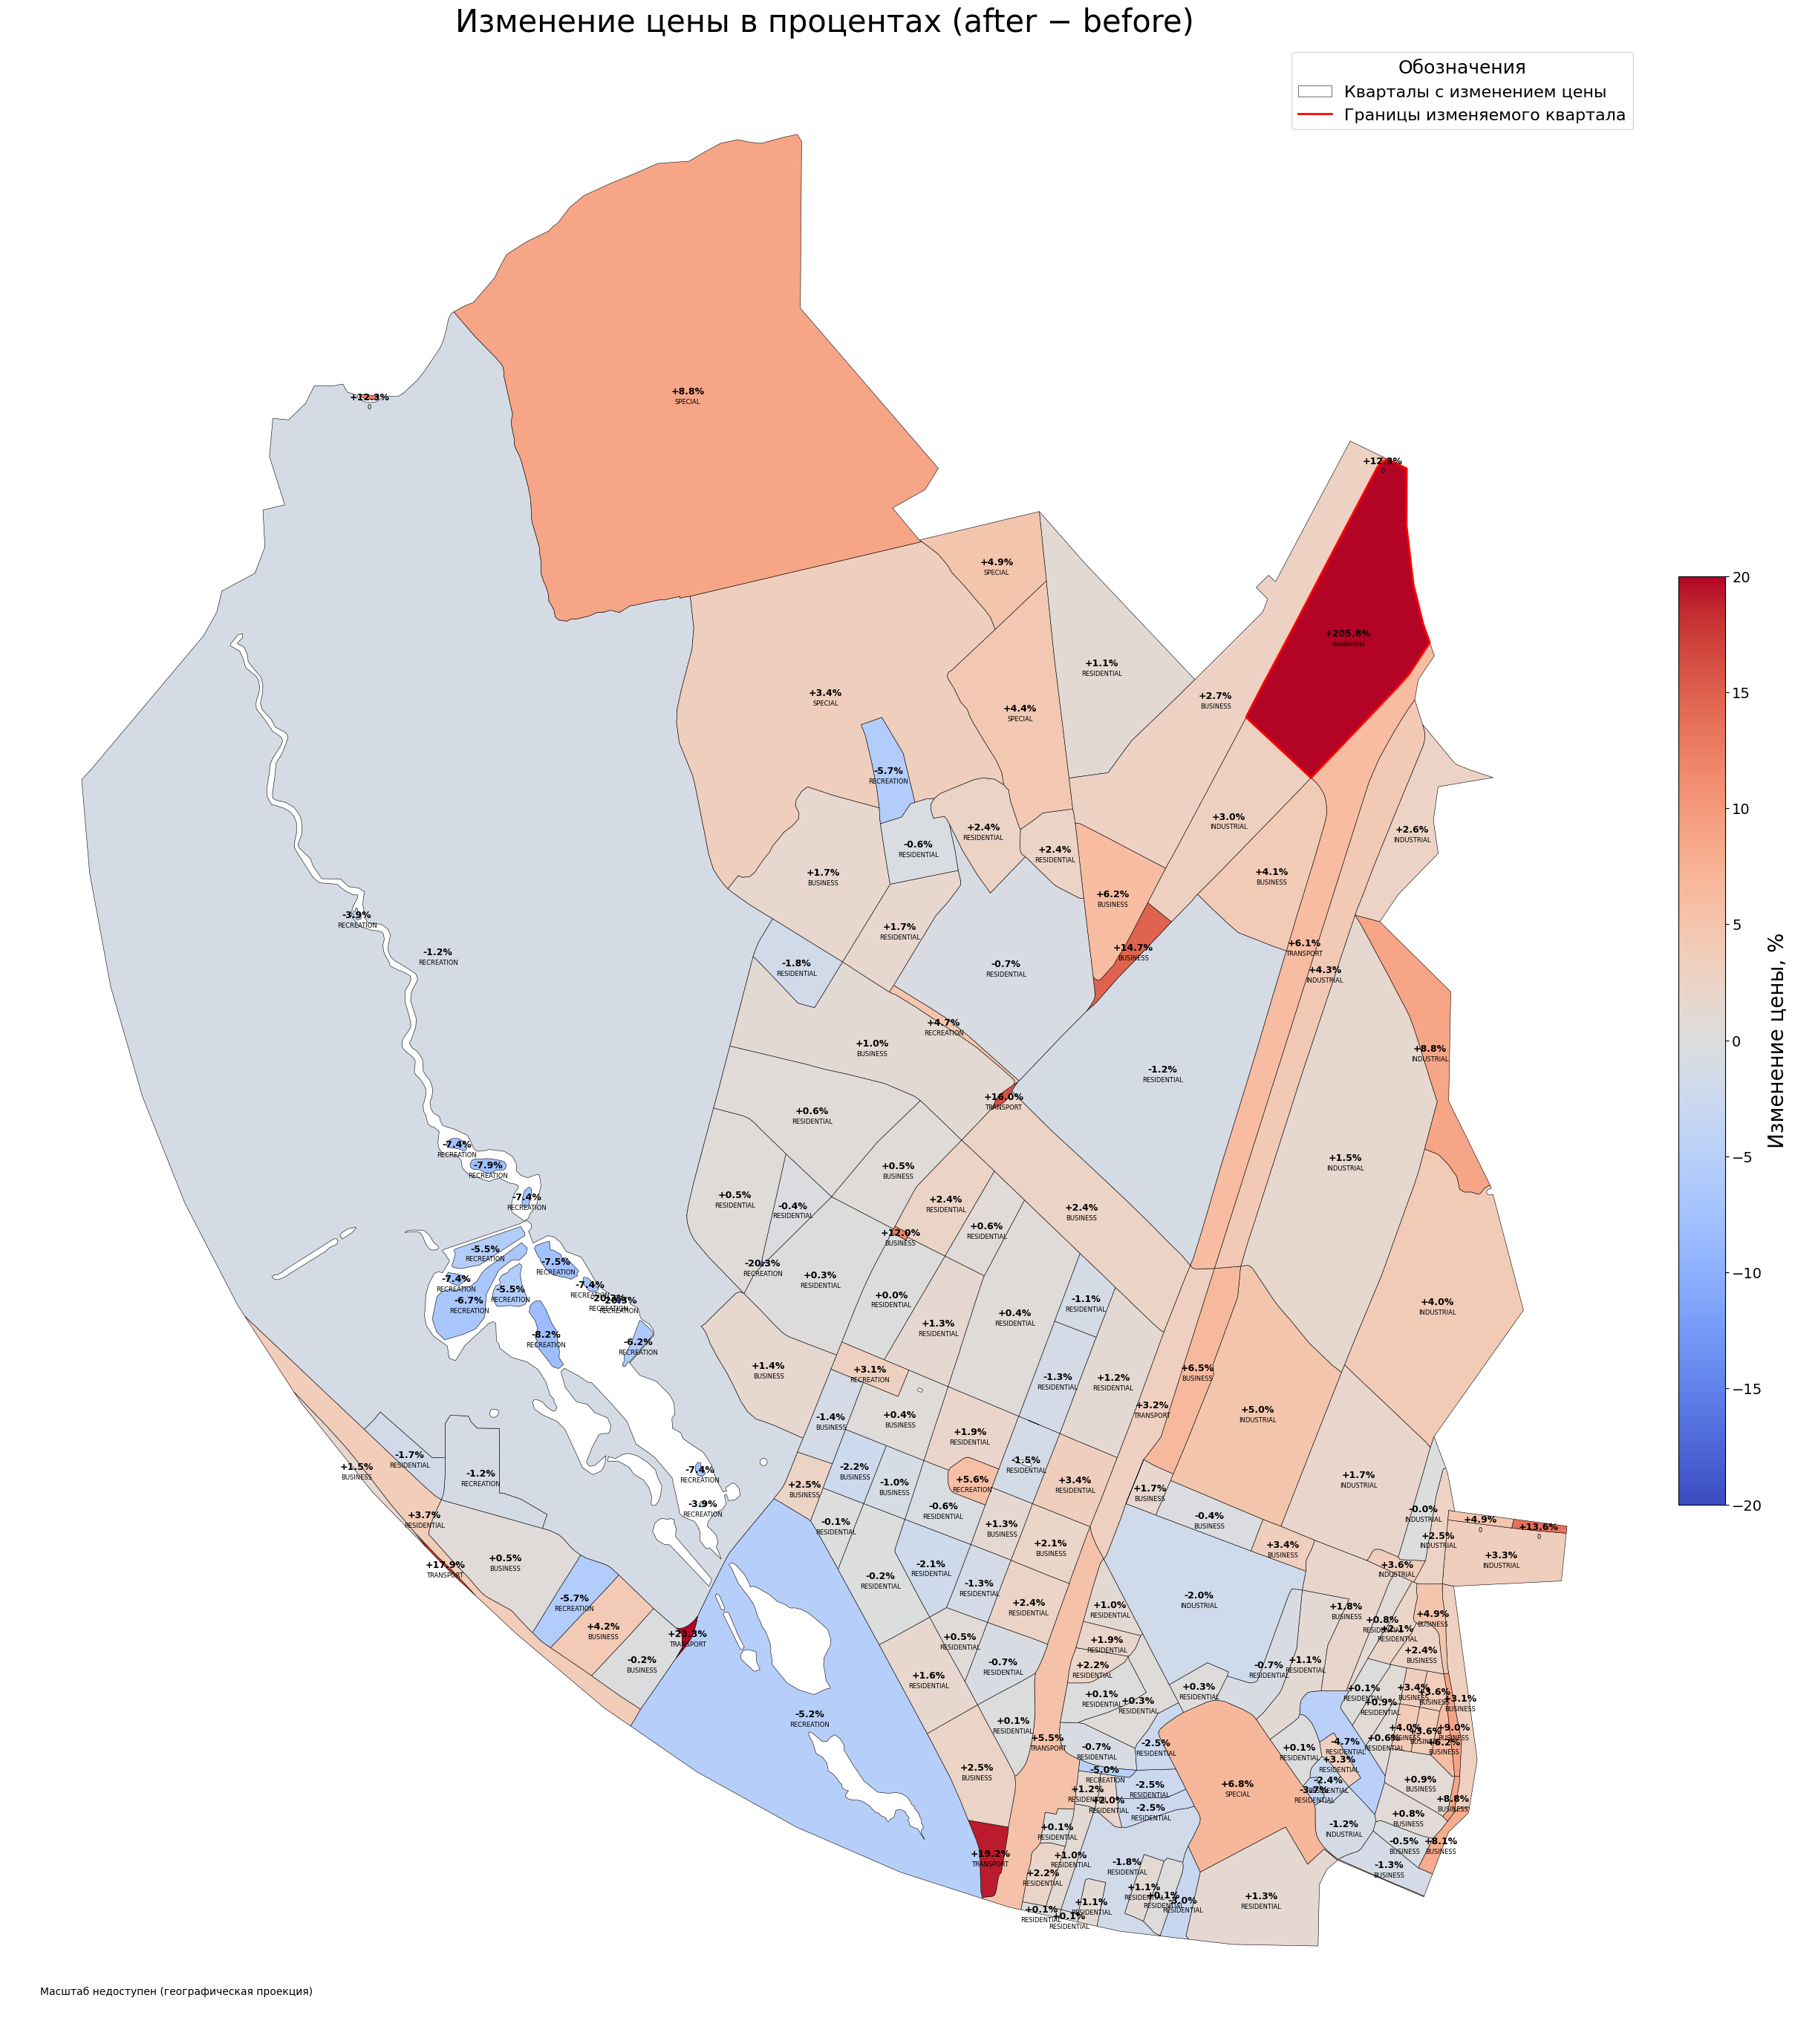


Статистика по кварталам в контексте (|Δ₽| > 1e-09):

Изменяемый квартал:
index | land_use | до (₽) → после (₽) | Δ₽ | Δ%
7 | residential | 195 468 342 ₽ → 597 807 782 ₽ | +402 339 440 ₽ | +205.8%

Кварталы в границах проекта:
Нет кварталов проекта с изменениями выше порога.

Кварталы в контексте:
index | land_use | до (₽) → после (₽) | Δ₽ | Δ%
346 | RESIDENTIAL | 265 890 509 ₽ → 269 334 131 ₽ | +3 443 621 ₽ | +1.3%
287 | RESIDENTIAL | 137 204 132 ₽ → 133 111 415 ₽ | -4 092 717 ₽ | -3.0%
140 | RESIDENTIAL | 61 929 261 ₽ → 61 981 274 ₽ | +52 013 ₽ | +0.1%
167 | BUSINESS | 41 854 921 ₽ → 41 293 035 ₽ | -561 886 ₽ | -1.3%
322 | BUSINESS | 26 912 297 ₽ → 26 772 410 ₽ | -139 887 ₽ | -0.5%
323 | BUSINESS | 3 794 420 ₽ → 4 100 989 ₽ | +306 570 ₽ | +8.1%
258 | INDUSTRIAL | 37 816 727 ₽ → 37 352 206 ₽ | -464 520 ₽ | -1.2%
166 | BUSINESS | 36 389 517 ₽ → 36 670 577 ₽ | +281 059 ₽ | +0.8%
252 | BUSINESS | 2 162 045 ₽ → 2 352 746 ₽ | +190 701 ₽ | +8.8%
118 | SPECIAL | 114 189 470 ₽ → 121 991 756 ₽

In [46]:
from urbanomy.methods.land_value_modeling import LandPriceEstimator

# 1) Применяем сценарные изменения к признакам блока
blocks_after_scenario = modifier.apply(target_idx, params_repaired)

# 2) Предсказываем новую стоимость земли для сценария
scenario_estimator = LandPriceEstimator(
    model=model,
    blocks=blocks_after_scenario,
    use_service_features=False,
)
blocks_after_scenario_pred = scenario_estimator.predict()
blocks_after_scenario_pred["land_value_per_100m2"] = (
    blocks_after_scenario_pred["land_value"] / blocks_after_scenario_pred["site_area"] * 100
)

# 3) Базовый набор "до" тоже должен содержать land_value
if "land_value" in blocks_after.columns:
    blocks_before_pred = blocks_after.copy()
else:
    baseline_estimator = LandPriceEstimator(
        model=model,
        blocks=blocks_after,
        use_service_features=False,
    )
    blocks_before_pred = baseline_estimator.predict()

if "land_value_per_100m2" not in blocks_before_pred.columns:
    blocks_before_pred["land_value_per_100m2"] = (
        blocks_before_pred["land_value"] / blocks_before_pred["site_area"] * 100
    )

# 4) Переносим baseline-цену в колонку land_value_before
blocks_full_value = transfer_baseline_prices(
    after_blocks=blocks_after_scenario_pred,
    before_blocks=blocks_before_pred,
    scenario_mode=False,
)

blocks_full_value = blocks_full_value.replace([np.inf, -np.inf], np.nan)
blocks_full_value = blocks_full_value.fillna(0)

# 5) Визуализация и статистика изменений
scenario_result = plot_scenario_impact(
    blocks=blocks_full_value,
    target_idx=target_idx,
    target_id_column="id",
    figsize=(25, 35),
)


In [47]:
import pandas as pd

blocks_gen = modifier.apply(target_idx, params_repaired)   # без запятой

gen_blocks = pd.DataFrame(blocks_gen)

gen_blocks.head()

,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,l,morphotype,area_accessibility,geometry,site_area,land_value,land_value_per_100m2,id,share_living,share_non_living
0,0.690207,0.211718,0.055976,0.0,0.042093,0.0,0.0,LandUse.RESIDENTIAL,0.690207,7383.849525,...,1.371459,individual residential,10.063987,"POLYGON ((30.09367 59.55207, 30.09375 59.55215...",215420.389645,2.918098e+08,135460.608081,0,NaN,NaN
1,0.970519,0.029484,0.000000,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.970519,15304.958732,...,5.824002,mid-rise,10.210398,"POLYGON ((30.09448 59.56164, 30.09448 59.56164...",108166.972589,3.119623e+08,288408.099091,1,NaN,NaN
2,0.936589,0.010562,0.052849,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.936589,17141.628200,...,5.365401,mid-rise,8.669212,"POLYGON ((30.12546 59.58002, 30.12541 59.57998...",77911.495727,2.421744e+08,310832.641383,2,NaN,NaN
3,0.121353,0.819171,0.059489,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.819171,9453.530183,...,2.288643,low-rise model,7.467434,"POLYGON ((30.12501 59.56588, 30.12497 59.56582...",32058.270586,8.120294e+07,253297.930854,3,NaN,NaN
4,0.068737,0.931312,0.000000,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.931312,8567.309559,...,2.187029,low-rise model,8.285434,"POLYGON ((30.1249 59.56574, 30.12497 59.56582,...",30779.356283,7.602283e+07,246992.918836,4,NaN,NaN


In [48]:
gen_blocks.iloc[7]

residential                                                      0.270467
business                                                         0.217809
recreation                                                        0.19369
industrial                                                       0.102368
transport                                                        0.183669
special                                                          0.027689
agriculture                                                      0.004309
land_use                                              LandUse.RESIDENTIAL
share                                                            0.270467
footprint_area                                               31335.432149
build_floor_area                                            248309.169576
living_area                                                  66017.949345
non_living_area                                             182291.220231
population                            

In [49]:
blocks_after.iloc[7]

residential                                                           0.0
business                                                              0.0
recreation                                                            0.0
industrial                                                       0.727595
transport                                                        0.000757
special                                                          0.200502
agriculture                                                           0.0
land_use                                               LandUse.INDUSTRIAL
share                                                            0.727595
footprint_area                                                3990.876381
build_floor_area                                              3990.876381
living_area                                                           0.0
non_living_area                                               3990.876381
population                            

In [44]:
gen_blocks = gen_blocks.copy()
gen_blocks["is_project"] = False

# target_idx — индекс изменяемого квартала
if target_idx in gen_blocks.index:
    gen_blocks.loc[target_idx, "is_project"] = True
else:
    raise KeyError(f"target_idx={target_idx} не найден в gen_blocks.index")

investment_input = prepare_investment_input(
    gdf=gen_blocks,
    project_potential=potential_df,
)

summary = an.calculate_investment_metrics(
    investment_input,
    discount_rate=0.18,
    show_project_totals=True
)
summary

2026-03-05 10:51:03.284 | WARNING  | urbanomy.utils.investment_input:prepare_investment_input:455 - prepare_investment_input: колонка 'land_value_before' не найдена; значения скопированы из 'land_value'.


Project totals:
 • Land area:          330,924.59
 • Built area:         248,309.17
 • Land value:         195,468,342.22
 • Demolition cost:    223,478,252.62
 • Construction cost:  11,173,912,630.92
 • Investment need:    11,592,859,225.77
 • Spatial potential:  0.00
 • Project NPV:        6,654,988,910.07
 • Project IRR:        0.38
 • Project ROI:        6.76
 • Project PP (yrs):   5.05
 • Project EI:         100.00
 • Project INV score:  60.00


,land_use,land_area,land_value_before,built_area,land_value,demolition_cost,construction_cost,investment_need,NPV,IRR,ROI,PP_years,EI,spatial_potential,INV
0,LandUse.RESIDENTIAL,330924.59,1.954683e+08,248309.17,1.954683e+08,2.234783e+08,1.117391e+10,1.159286e+10,6.654989e+09,0.38,6.76,5.05,100.0,0.0,60.0


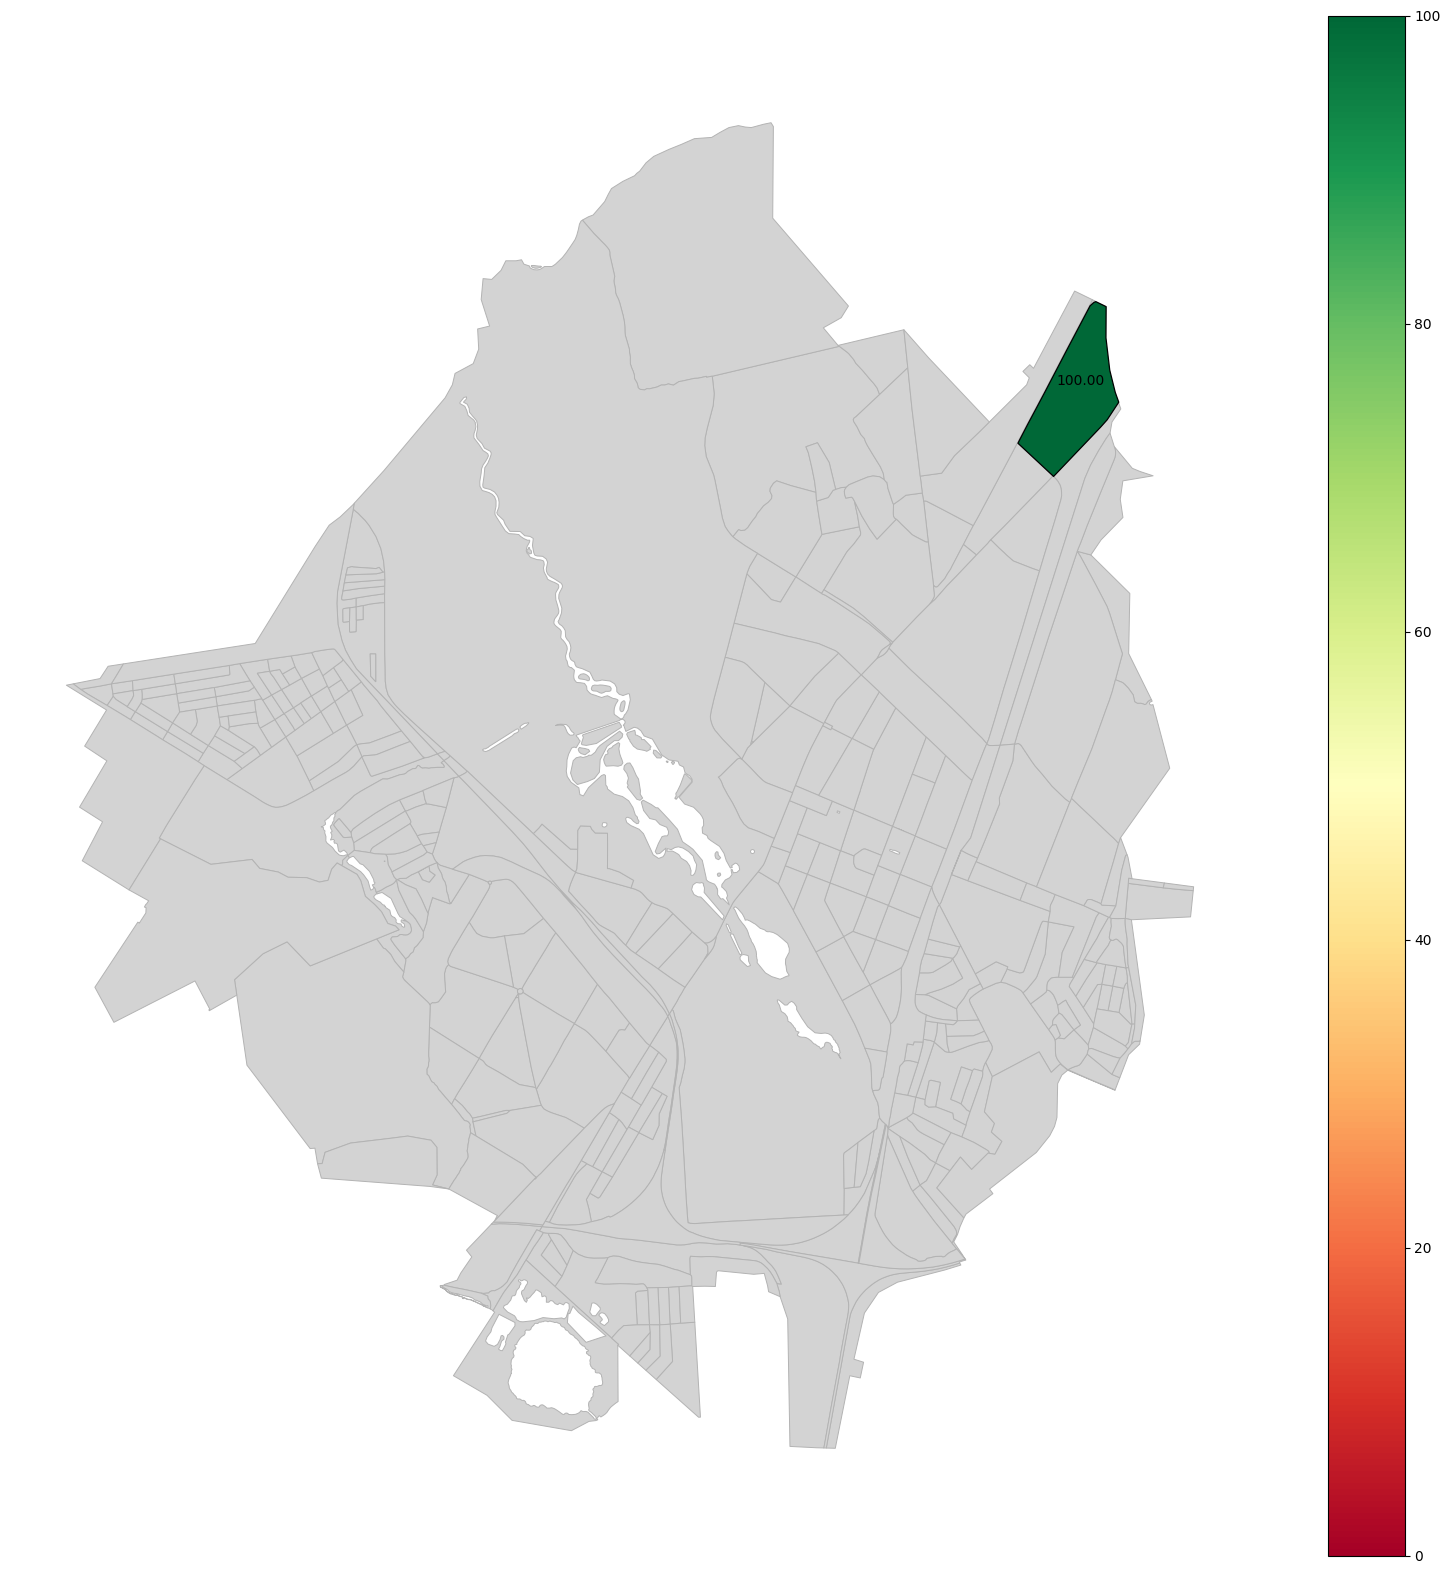

In [42]:
# 1) кладём summary на нужный индекс
summary_idxed = summary.copy()
summary_idxed.index = [target_idx]  # если одна строка; иначе set_index по id

# 2) собираем слой
scn = blocks_after[["geometry"]].join(summary_idxed, how="left")
scn["is_project"] = scn.index == target_idx

column = "EI"
vmin, vmax = 0, 100

fig, ax = plt.subplots(figsize=(20, 20))
scn.loc[~scn["is_project"]].plot(ax=ax, color="lightgrey", edgecolor="0.7", linewidth=0.7)

scn_proj = scn.loc[scn["is_project"]]
if len(scn_proj):
    scn_proj.plot(
        ax=ax,
        column=column,
        cmap="RdYlGn",
        legend=True,
        edgecolor="black",
        linewidth=0.9,
        vmin=vmin,
        vmax=vmax,
    )
    for _, row in scn_proj.dropna(subset=[column]).iterrows():
        x, y = row.geometry.representative_point().coords[0]
        ax.text(x, y, f"{row[column]:.2f}", ha="center", va="center", fontsize=10, color="black")

ax.set_axis_off()
plt.show()

In [43]:
from urbanomy.methods.socio_economic_indicators.sei_calculate import SEREstimator

deafaut_cfg = {
    "population": 91_000,
}

est = SEREstimator(deafaut_cfg) # or use project_cfg
result = est.compute(scn, pretty=True)
result

,indicator,delta_total
0,Объём инвестиций в основной капитал на душу на...,122 790
1,Валовый региональный продукт на душу населения,60 713
2,Доходы бюджета территории,670 434 758
3,Средний уровень заработной платы,0.0000
4,Износ основного фонда (тыс. руб.),318 457
